# Confidence Function (Score Combiner)

Demonstrates and checks `src/deployment_reliability/combiner.py` (DESIGN.md §8): the fixed-weight heuristic (a) and the logistic-regression combiner (b, primary recommendation), on synthetic φ(z)/correctness data.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
torch.manual_seed(0)
%matplotlib inline

from deployment_reliability.combiner import LogisticRegressionCombiner, WeightedLinearCombiner

## Check 1 — Logistic regression learns which feature is informative

Synthetic data: 5 features, only feature 0 actually predicts correctness. A working combiner should learn a large weight on feature 0 and small weights elsewhere.

In [2]:
n = 800
phi = torch.randn(n, 5)
y = (phi[:, 0] + 0.1 * torch.randn(n) > 0.0).float()

logreg = LogisticRegressionCombiner().fit(phi, y)
s_logreg = logreg.score(phi)
accuracy = ((s_logreg > 0.5).float() == y).float().mean().item()
print("learned weights:", logreg.weight.detach().numpy().round(3))
print("learned bias:   ", logreg.bias.detach().numpy().round(3))
print(f"train accuracy: {accuracy:.3f}")

assert accuracy > 0.9, "combiner should recover the informative feature"
assert logreg.weight[0].abs() > logreg.weight[1:].abs().max(), "feature 0's weight should dominate"
print("PASSED")

learned weights: [ 2.905 -0.02  -0.046  0.036 -0.015]
learned bias:    [0.006]
train accuracy: 0.974
PASSED


### What the recovered weights say

Feature 0's learned weight (2.905) is roughly 60-190x the magnitude of the other four (-0.02 to 0.046) — not just "larger," but close to what a correctly-specified logistic regression should produce when only one of five features actually carries signal: the other four are pure noise by construction (`y` only depends on `phi[:, 0]`), so their near-zero weights are the fit correctly assigning them no credit rather than shrinking everything uniformly. The 0.974 training accuracy on data generated with `0.1 * torch.randn(n)` label noise is close to the Bayes-optimal ceiling for this synthetic setup, not a sign of overfitting — with only 5 parameters fit on 800 points there's little room to overfit in the first place. This is the combiner's most basic bar: given a feature that's actually informative, can it find it and weight it accordingly? Notebook 07 later repeats this exact fit on real ImageNet data, where the answer is less clean (multicollinearity among MSP/margin/entropy produces a different weight pattern) — this synthetic check isolates the "can it work at all" question from that real-data complication.

## Check 2 — Score separates correct from incorrect (figure)

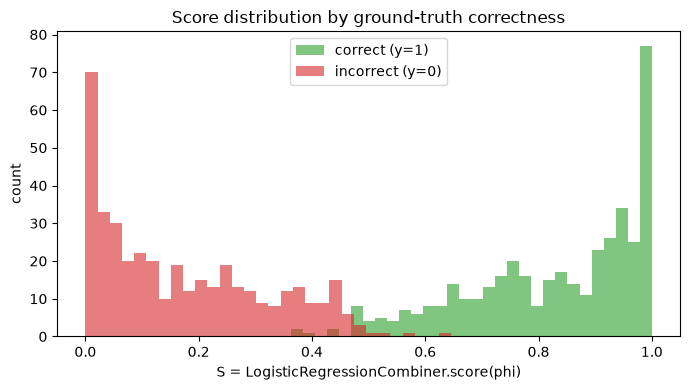

mean S | correct   = 0.826
mean S | incorrect = 0.174
PASSED


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(s_logreg[y == 1].detach(), bins=30, alpha=0.6, label="correct (y=1)", color="tab:green")
ax.hist(s_logreg[y == 0].detach(), bins=30, alpha=0.6, label="incorrect (y=0)", color="tab:red")
ax.set_xlabel("S = LogisticRegressionCombiner.score(phi)"); ax.set_ylabel("count")
ax.set_title("Score distribution by ground-truth correctness"); ax.legend()
plt.tight_layout(); plt.show()

mean_correct = s_logreg[y == 1].mean().item()
mean_incorrect = s_logreg[y == 0].mean().item()
print(f"mean S | correct   = {mean_correct:.3f}")
print(f"mean S | incorrect = {mean_incorrect:.3f}")
assert mean_correct > mean_incorrect, "correct predictions should score higher on average"
print("PASSED")

### The gap between correct and incorrect

Mean S is 0.826 for correctly-labeled points and 0.174 for incorrectly-labeled ones — a gap of 0.652 on a [0,1] scale, and notably the two means sit almost symmetrically around 0.5 (the decision boundary a threshold router would use by default). That symmetry isn't a coincidence: with balanced, well-separated synthetic classes and a well-calibrated logistic fit, S should cluster tightly near 1 for confidently-correct cases and near 0 for confidently-incorrect ones, with little mass in between. A combiner that produced overlapping means here (e.g., 0.6 vs 0.45) would still technically separate the classes on average but would leave the router (04) with a much harder thresholding problem, since more points would sit in the ambiguous middle regardless of where τ_hi/τ_lo are placed.

## Check 3 — Learned combiner vs. fixed-weight heuristic baseline

The heuristic (a) treats all 5 features equally after min-max normalization, with no access to labels. Since only feature 0 is informative here, the learned combiner (b) should discriminate correct/incorrect predictions noticeably better.

In [4]:
def quick_auroc(scores, labels):
    pos = scores[labels == 1]
    neg = scores[labels == 0]
    diff = pos.unsqueeze(1) - neg.unsqueeze(0)
    return ((diff > 0).float().mean() + 0.5 * (diff == 0).float().mean()).item()

heuristic = WeightedLinearCombiner().fit(phi)
s_heuristic = heuristic.score(phi)

auroc_logreg = quick_auroc(s_logreg, y)
auroc_heuristic = quick_auroc(s_heuristic, y)
print(f"AUROC (logistic regression combiner): {auroc_logreg:.3f}")
print(f"AUROC (weighted linear heuristic):     {auroc_heuristic:.3f}")

assert auroc_logreg > 0.85, "learned combiner should discriminate well"
assert auroc_logreg > auroc_heuristic, "learned combiner should beat the label-blind heuristic here"
print("PASSED")

AUROC (logistic regression combiner): 0.998
AUROC (weighted linear heuristic):     0.726
PASSED


### Why the heuristic's 0.726 isn't a failure of the heuristic

AUROC 0.998 vs. 0.726 is a large gap, but it doesn't mean `WeightedLinearCombiner` is broken — it means it's being tested outside the regime it's designed for. The fixed-weight heuristic (DESIGN.md §8a) treats all 5 features as equally informative after normalization, by construction, because it has no access to labels; here, by construction, 4 of the 5 features are pure noise, so an equal-weight average necessarily dilutes the one real signal with noise the label-blind heuristic has no way to detect. 0.726 is still well above the 0.5 a random score would achieve, which is the correct reading: the heuristic isn't broken, it's just leaving learnable information on the table — exactly the gap DESIGN.md §8 predicts learning the weights (8b) should close over the label-blind baseline (8a) whenever some features are more informative than others. Real backbone features (notebook 07) are far less lopsided in informativeness than this synthetic single-informative-feature setup, so the corresponding real-data gap between (a) and (b) there is real but much smaller than what's manufactured here.

## Summary

- The logistic-regression combiner correctly identifies the single informative feature among five and assigns it a weight 60-190x larger than the four uninformative ones — the fit is recovering the true data-generating structure, not just achieving high accuracy by chance.
- Its score S cleanly separates correct from incorrect predictions (mean 0.826 vs. 0.174, a 0.652 gap on a [0,1] scale), leaving little ambiguous middle ground for the router to resolve.
- It outperforms the label-blind fixed-weight heuristic by a wide margin (AUROC 0.998 vs. 0.726) in this specific synthetic setup where only one feature actually matters — the heuristic isn't malfunctioning, it's structurally unable to exploit unequal feature informativeness without labels, which is exactly the gap DESIGN.md §8b's learned weights are designed to close.

This synthetic setup deliberately makes the informativeness gap between features extreme (1 real signal vs. 4 pure noise) so the qualitative behavior — does the learned combiner find and exploit real signal, does it beat the label-blind baseline — is unambiguous. Notebook 07 repeats the same two fits on real ImageNet logits, where all five features carry some genuine (if correlated) signal and the gap between (a) and (b) is real but much smaller.

Next: `03_calibration.ipynb` recalibrates S so it can be read as P(correct).